In [9]:
import numpy as np
import xarray as xr
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d

import glob
import os
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import cmocean


from swot_analysis import compute_pass_spectra
from swot_analysis import load_swot_l2_expert 


In [226]:
def build_box_dataset(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      method: str = 'mean',
                      min_sampling_fraction: float = 0.5) -> xr.Dataset:
    from collections import defaultdict
    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)
    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)
    psd_all    = ds_segments['psd'].values
    wavenumber = ds_segments['wavenumber'].values
    rows_lat, rows_lon, rows_n, rows_psd = [], [], [], []
    for (li, loi), idxs in sorted(box_to_segs.items()):
        if method=='mean':
            rows_psd.append(np.nanmean(psd_all[idxs, :], axis=0))
        elif method=='median':
            rows_psd.append(np.nanmedian(psd_all[idxs, :], axis=0))
        elif method == "log":
            log_spectra = np.log(psd_all[idxs, :])          # natural log; log10 works identically up to a constant
            rows_psd.append(np.exp(np.nanmean(log_spectra, axis=0)))
         
        else:
            print("Method is not defined!")
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)
    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_fraction * n_max
    psd_stack  = np.stack(rows_psd, axis=0)
    lat_mean   = np.array(rows_lat)
    lon_mean   = np.array(rows_lon)
    return xr.Dataset(
        data_vars=dict(
            mean_psd=(['box', 'wavenumber'], psd_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
        ),
        coords=dict(wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
            lat_mean=('box', lat_mean[keep], {'units': 'degrees_north'}),
            lon_mean=('box', lon_mean[keep], {'units': 'degrees_east'}),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_fraction),
    )


def plot_box(var: np.array, lon: np.array, lat: np.array,
             box_deg: float = None,
             projection: ccrs = ccrs.Robinson(), cmap: str = "viridis",
             figsize: tuple = (14, 7),
             title: str = "Number of observations per box", label: str = "Number of observations",
             norm: norm = None, vmin: float = None, vmax: float = None,
             fig: fig = None, ax: ax = None
            ):
    mask = np.isfinite(var)
    lon = lon[mask]
    lat = lat[mask]
    var = var[mask]

    # Infer box size from the spacing of box centers if not given
    if box_deg is None:
        lat_diffs = np.diff(np.unique(np.round(lat, 6)))
        lon_diffs = np.diff(np.unique(np.round(lon, 6)))
        box_deg = np.min(np.concatenate([lat_diffs, lon_diffs]))

    # Reconstruct the regular grid of box centers
    lat_centers = np.arange(lat.min(), lat.max() + box_deg, box_deg)
    lon_centers = np.arange(lon.min(), lon.max() + box_deg, box_deg)

    lat_idx = np.round((lat - lat_centers[0]) / box_deg).astype(int)
    lon_idx = np.round((lon - lon_centers[0]) / box_deg).astype(int)

    grid = np.full((lat_centers.size, lon_centers.size), np.nan)
    grid[lat_idx, lon_idx] = var

    # pcolormesh wants cell edges, not centers
    lat_edges = np.concatenate([lat_centers - box_deg / 2, [lat_centers[-1] + box_deg / 2]])
    lon_edges = np.concatenate([lon_centers - box_deg / 2, [lon_centers[-1] + box_deg / 2]])

    if ax is None:
        fig = plt.figure(figsize=figsize)
        ax = plt.axes(projection=projection)
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="0.9", edgecolor="none")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.5)

    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))
    gl.xlabel_style = {"size": 10, "color": "black"}
    gl.ylabel_style = {"size": 10, "color": "black"}

    if norm is not None:
        sc = ax.pcolormesh(lon_edges, lat_edges, grid,
                            cmap=cmap, shading='flat',
                            transform=ccrs.PlateCarree(), norm=norm)
    else:
        if vmin is None:
            vmin, vmax = np.nanmin(var), np.nanmax(var)

        sc = ax.pcolormesh(lon_edges, lat_edges, grid,
                            cmap=cmap, shading='flat',
                            transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax)

    cb = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.03)
    cb.set_label(label)
    ax.set_title(title)

    return fig, ax
def estimate_separation_scale_adaptative(psd_all,
                                         wavenumber,
                                         log_k_uniform,
                                         dlogk,
                                         search_mask,
                                         low_k_band: tuple,
                                         high_k_band: tuple,
                                         smooth_window: int = 7,
                                         polyorder: int = 2,
                                         search_range: tuple = None,
                                         n_interp: int = 200,
                                         verbose: bool = False) -> xr.Dataset:
    
    p = psd_all
    valid = np.isfinite(p) & (p > 0)
    #if valid.sum() < smooth_window:
    #    continue
    k = wavenumber[valid]
    logp = np.log10(p[valid])
    
    # --- Plateau slopes: simple linear fit on RAW (unsmoothed)
    # points within each band, so no window-straddling bias here ---
    low_mask = (k >= low_k_band[0]) & (k <= low_k_band[1])
    high_mask = (k >= high_k_band[0]) & (k <= high_k_band[1])

    if low_mask.sum() < 3 or high_mask.sum() < 3:
        if verbose:
            print(f"Box {i}: not enough points in plateau bands "
                  f"(low={low_mask.sum()}, high={high_mask.sum()}), skipping.")
   #     continue

    slope_low = np.polyfit(np.log10(k[low_mask]), logp[low_mask], 1)[0]
    slope_high = np.polyfit(np.log10(k[high_mask]), logp[high_mask], 1)[0]
    #slope_low_all[i] = slope_low
    #slope_high_all[i] = slope_high

    # Adaptive threshold: midpoint between the two plateau slopes
    threshold = 0.5 * (slope_low + slope_high)
    #threshold_used[i] = threshold

    # Expect mesoscale (low-k) STEEPER than sub-mesoscale (high-k),
    # i.e. slope_low < slope_high (more negative = steeper).
    if slope_low >= slope_high:
        if verbose:
            print(f"Box {i}: low-k slope ({slope_low:.2f}) not steeper "
                  f"than high-k slope ({slope_high:.2f}) — no clear "
                  f"mesoscale-to-submesoscale steepening-to-shallowing "
                  f"transition, skipping.")
     #   continue

    
    # --- Local slope curve via SG, same as before ---
    interp_fn = interp1d(np.log10(k), logp, bounds_error=False, fill_value=np.nan)
    logp_uniform = interp_fn(log_k_uniform)
    valid_u = ~np.isnan(logp_uniform)
    #if valid_u.sum() < smooth_window:
    #    continue

    
    slope_curve = np.full(n_interp, np.nan)
    win = min(smooth_window, valid_u.sum() if valid_u.sum() % 2 == 1 else valid_u.sum() - 1)
    #if win <= polyorder:
    #    continue
    slope_curve[valid_u] = savgol_filter(logp_uniform[valid_u], window_length=win,
                                              polyorder=polyorder, deriv=1, delta=dlogk)

    mask = search_mask & valid_u
    idxs = np.where(mask)[0]
   # if len(idxs) < 2:
    #    if verbose:
    #            print(f"Box {i}: fewer than 2 points in search range, skipping.")
      #  continue

    diff = slope_curve[idxs] - threshold
    sign_change = np.where(np.diff(np.sign(diff)) != 0)[0]
   # if len(sign_change) == 0:
    #    if verbose:
   #         print(f"Box {i}: slope never crosses adaptive threshold "
   #               f"{threshold:.2f}.")
   #  #   continue

    j = sign_change[0]
    frac = -diff[j] / (diff[j + 1] - diff[j])
    i1, i2 = idxs[j], idxs[j + 1]
    log_k_cross = log_k_uniform[i1] + frac * (log_k_uniform[i2] - log_k_uniform[i1])
    separation_k = 10 ** log_k_cross
    return separation_k, threshold,slope_low, slope_high
    
def wrap_separation_scale_adaptive(ds_box: xr.Dataset,
                                        low_k_band: tuple,
                                        high_k_band: tuple,
                                        smooth_window: int = 7,
                                        polyorder: int = 2,
                                        search_range: tuple = None,
                                        n_interp: int = 200,
                                        verbose: bool = False) -> xr.Dataset:
    """
    Non-parametric separation scale using an adaptive (per-box) slope
    threshold, calibrated to each spectrum's own mesoscale (low-k, steep)
    and sub-mesoscale (high-k, shallower) plateau slopes, instead of a
    fixed universal reference slope like -2.

    Physical convention: mesoscale (low-k) is expected to be steeper
    (more negative slope) than sub-mesoscale (high-k), consistent with
    the transition from geostrophic/QG turbulence (~ -5 to -11/3) to a
    shallower sub-mesoscale regime (~ -2 to -5/3).

    Parameters
    ----------
    low_k_band, high_k_band : tuple(float, float)
        Wavenumber ranges (cycles/km) used to estimate the plateau slope
        on each side of the transition, well away from the break itself.
    smooth_window, polyorder : SG smoothing parameters for the local-slope
        curve used to locate the crossing.
    search_range : tuple(float, float), optional
        Restrict the crossing search to this wavenumber range (defaults
        to the union of low_k_band and high_k_band).
    """
    wavenumber = ds_box['wavenumber'].values
    psd_all    = ds_box['mean_psd'].values
    n_boxes    = psd_all.shape[0]

    k_valid = wavenumber > 0
    wavenumber = wavenumber[k_valid]
    psd_all = psd_all[:, k_valid]
    log_k_orig = np.log10(wavenumber)

    if smooth_window % 2 == 0:
        smooth_window += 1

    log_k_uniform = np.linspace(log_k_orig.min(), log_k_orig.max(), n_interp)
    dlogk = log_k_uniform[1] - log_k_uniform[0]

    if search_range is None:
        k_lo = low_k_band[0]
        k_hi = high_k_band[1]
    else:
        k_lo, k_hi = search_range
    search_mask = (10**log_k_uniform >= k_lo) & (10**log_k_uniform <= k_hi)

    separation_k    = np.full(n_boxes, np.nan)
    slope_low_all   = np.full(n_boxes, np.nan)
    slope_high_all  = np.full(n_boxes, np.nan)
    threshold_used  = np.full(n_boxes, np.nan)

    for i in range(n_boxes):
        sep_k, threshold,slope_low, slope_high = estimate_separation_scale_adaptative(psd_all[i],wavenumber,log_k_uniform,dlogk,
                                                                                      search_mask,
                                                                                      low_k_band, high_k_band,
                                                                                     smooth_window = smooth_window,
                                                                                     polyorder=polyorder,
                                                                                     search_range = search_range,
                                                                                     n_interp=n_interp,
                                                                                     verbose=verbose)
        separation_k[i] = sep_k
        threshold_used[i] = threshold
        slope_low_all[i] = slope_low
        slope_high_all[i] = slope_high

    ds_out = ds_box.copy()
    ds_out['separation_wavenumber'] = (
        ['box'], separation_k,
        {'long_name': 'Wavenumber of adaptive-threshold slope crossing '
                       '(mesoscale-to-submesoscale transition)',
         'units': 'cycles/km'}
    )
    ds_out['separation_wavelength'] = (
        ['box'], 1.0 / separation_k,
        {'long_name': 'Separation scale (1/wavenumber)', 'units': 'km'}
    )
    ds_out['slope_low_k'] = (['box'], slope_low_all,
                              {'long_name': 'Fitted mesoscale (low-k) plateau slope'})
    ds_out['slope_high_k'] = (['box'], slope_high_all,
                               {'long_name': 'Fitted sub-mesoscale (high-k) plateau slope'})
    ds_out['adaptive_threshold'] = (['box'], threshold_used,
                                     {'long_name': 'Midpoint slope threshold used per box'})
    return ds_out

In [206]:
# ── Input files ───────────────────────────────────────────────────────────────
DATA_DIR    = '/Volumes/PortableSSD/'#'/Users/zoecas/Documents/data/'
#DATA_DIR    = '/Users/zoecas/Documents/data/'

DATA_SUBDIR = 'diags_2024/'


# ── Region of interest ────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = -60.0,60.0
LON_MIN, LON_MAX = 0.0,360.0

# ── File parameters ───────────────────────────────────────────────────────
SEGMENT_LENGTH_KM = 1000.0
BOX_DEG = 2.0
#filename_pattern = f'{int(SEGMENT_LENGTH_KM)}km_notide_demean_sw6.nc'
filename_pattern ="1000km_demean_swh5.nc"


# ── Expert-product variable names ─────────────────────────────────────────────
SSH_VAR = 'ssha_karin_2'
HRET    = False   # add internal tide correction (height_cor_xover + internal_tide_hret)

In [295]:
ds_segments = xr.open_dataset(DATA_DIR+DATA_SUBDIR+'swot_segments2D_'+filename_pattern)

print(f'Segment dataset: {ds_segments.sizes}')

ds_boxes = build_box_dataset(ds_segments, box_deg=BOX_DEG,min_sampling_fraction=0.15)

## comparing to smaller scales PSD
comparing = True

if comparing:
    ds_segments_250 = xr.open_dataset(DATA_DIR+DATA_SUBDIR+'swot_segments_500km_demean_swh5.nc')
    ds_boxes_250 = build_box_dataset(ds_segments_250, box_deg=BOX_DEG,min_sampling_fraction=0.15)

Segment dataset: Frozen({'segment': 302379, 'wavenumber': 250})


## Averaging method

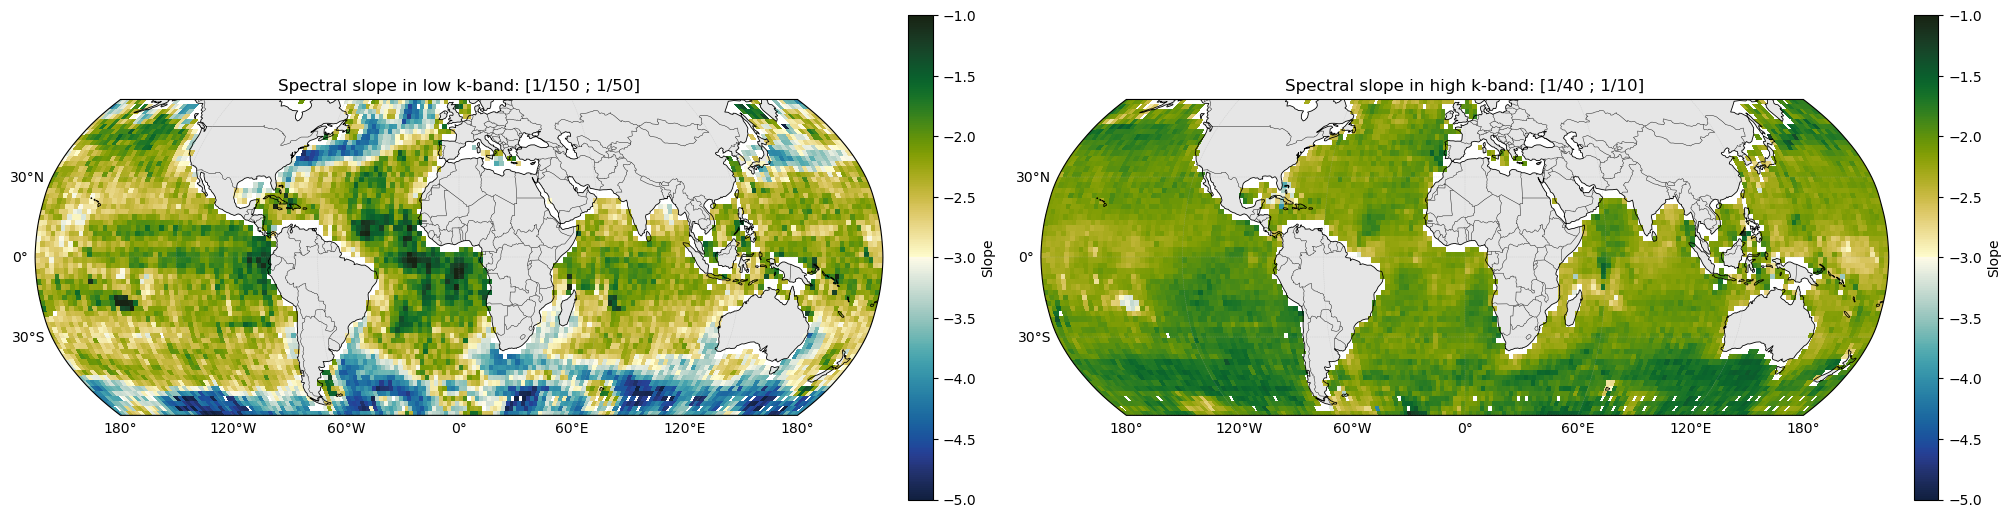

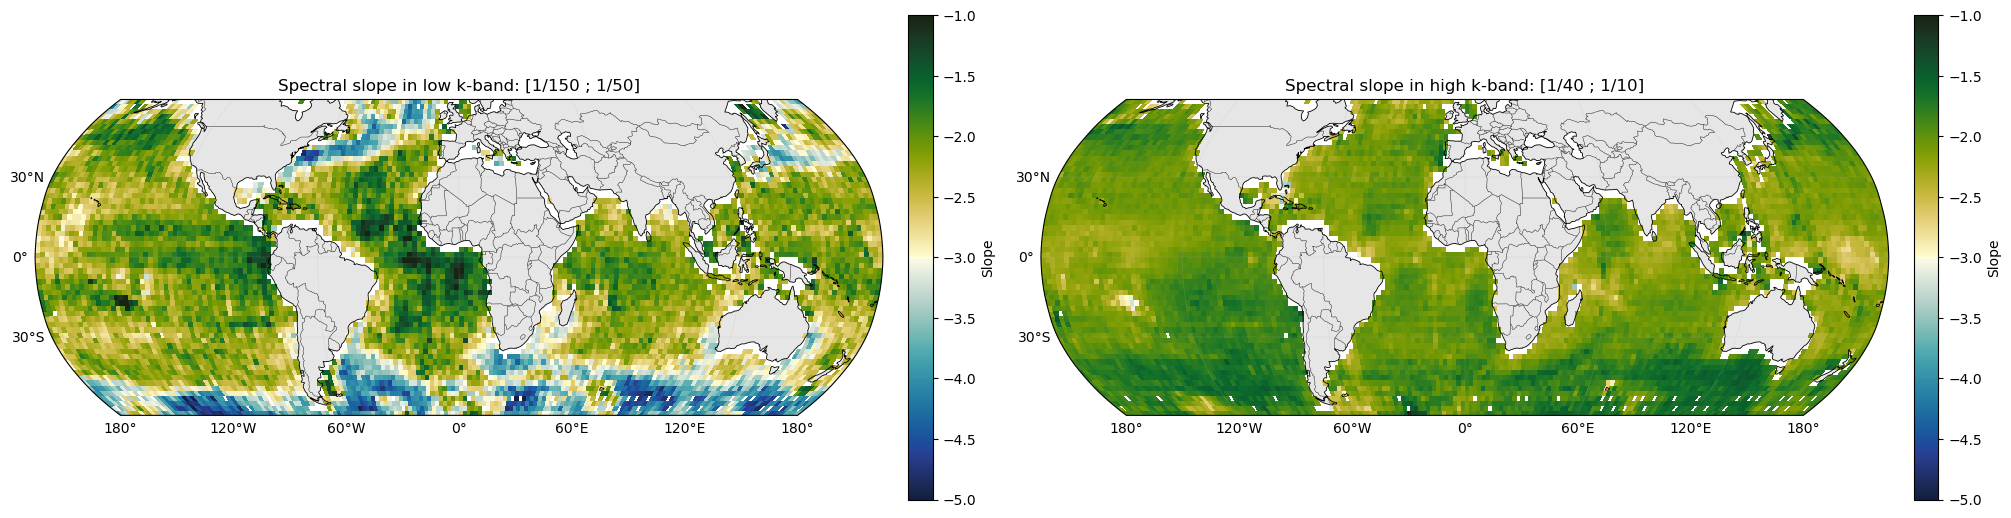

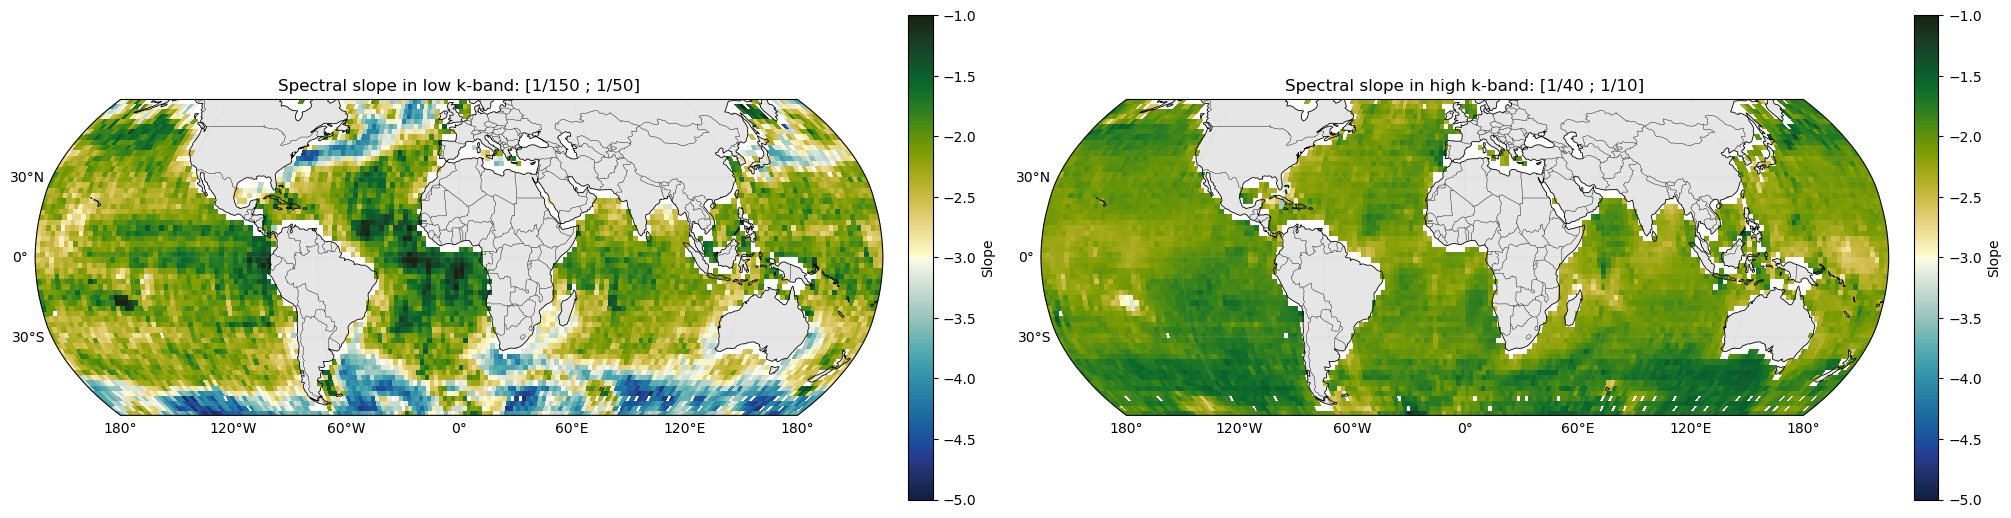

In [296]:
for method in ['mean','median','log']:
    ds_boxes = build_box_dataset(ds_segments, box_deg=BOX_DEG,min_sampling_fraction=0.15,method=method)
    ds_sep_adapt = wrap_separation_scale_adaptive(
    ds_boxes,
    low_k_band=(1/150, 1/50),   
    high_k_band=(1/50, 1/10),
    smooth_window=15,
    verbose=False,
    )
    fig, axs = plt.subplots(1,2,figsize=(20,7),subplot_kw={"projection": ccrs.Robinson()},constrained_layout=True)
    fig_, ax = plot_box(ds_sep_adapt.slope_high_k,
                   ds_sep_adapt.lon_mean,ds_sep_adapt.lat_mean, vmin=-5.0, vmax=-1.0,
                    fig=fig, ax=axs[1],
                   title = r"Spectral slope in high k-band: [1/40 ; 1/10]", label=r'Slope',
                  cmap=cmocean.cm.delta)
    ax.set_extent([-180,180,-60,60])
    fig_, ax = plot_box(ds_sep_adapt.slope_low_k,
                   ds_sep_adapt.lon_mean,ds_sep_adapt.lat_mean, vmin=-5.0, vmax=-1.0,
                    fig=fig, ax=axs[0],
                   title = r"Spectral slope in low k-band: [1/150 ; 1/50]", label=r'Slope',
                  cmap=cmocean.cm.delta)
    ax.set_extent([-180,180,-60,60])

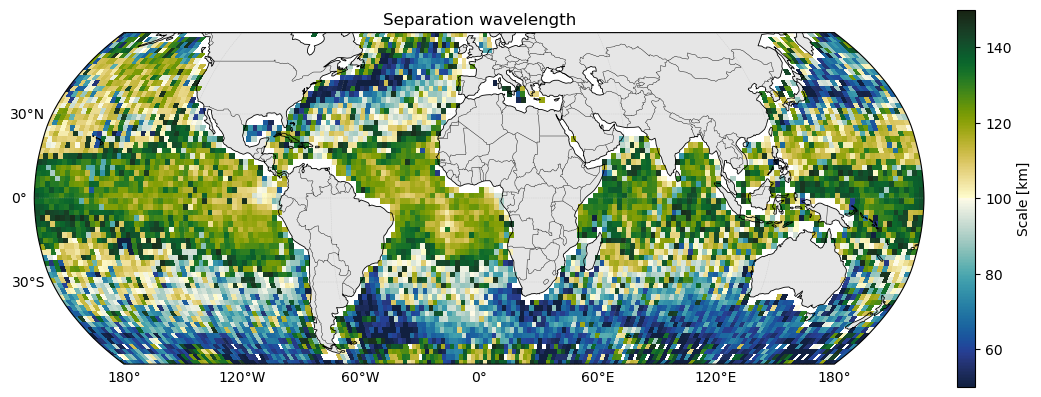

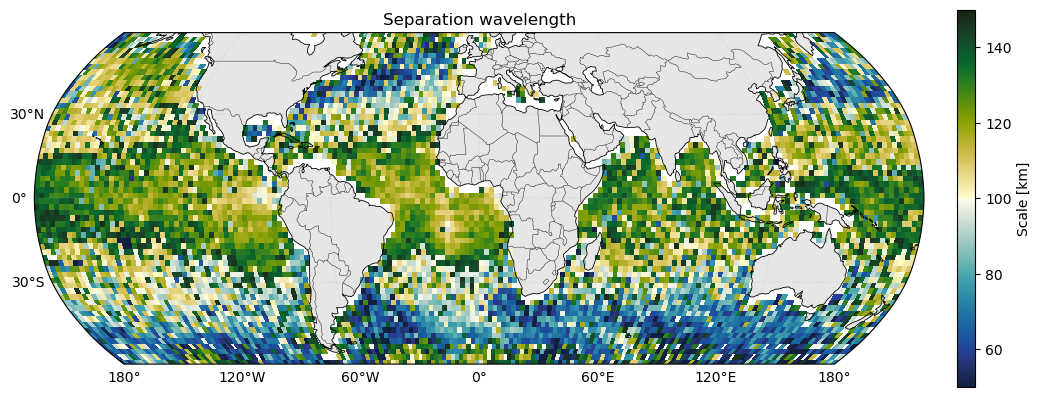

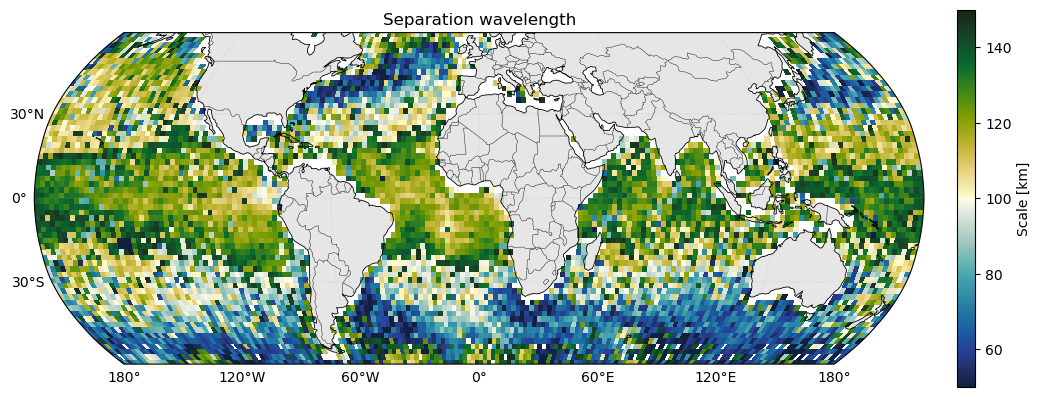

In [297]:
for method in ['mean','median','log']:
    ds_boxes = build_box_dataset(ds_segments, box_deg=BOX_DEG,min_sampling_fraction=0.15,method=method)
    ds_sep_adapt = wrap_separation_scale_adaptive(
    ds_boxes,
    low_k_band=(1/150, 1/50),   
    high_k_band=(1/50, 1/10),
    smooth_window=15,
    verbose=False,
    )
    
    fig, ax = plot_box(ds_sep_adapt.separation_wavelength,
                       ds_sep_adapt.lon_mean,ds_sep_adapt.lat_mean, vmin=50.0, vmax=150.0,
                       title = r"Separation wavelength", label=r'Scale [km]',
                      cmap=cmocean.cm.delta)
    ax.set_extent([-180,180,-60,60])

In [298]:
def convert2latlon(energy, lat, lon):
    lat_centers = np.arange(lat.min(), lat.max() + BOX_DEG, BOX_DEG)
    lon_centers = np.arange(lon.min(), lon.max() + BOX_DEG, BOX_DEG)

    lat_idx = np.round((lat - lat_centers[0]) / BOX_DEG).astype(int)
    lon_idx = np.round((lon - lon_centers[0]) / BOX_DEG).astype(int)

    grid = np.full((lat_centers.size, lon_centers.size), np.nan)
    grid[lat_idx, lon_idx] = energy

    # pcolormesh wants cell edges, not centers
    lat_edges = np.concatenate([lat_centers - BOX_DEG / 2, [lat_centers[-1] + BOX_DEG / 2]])
    lon_edges = np.concatenate([lon_centers - BOX_DEG / 2, [lon_centers[-1] + BOX_DEG / 2]])
    return xr.DataArray(grid,dims=['lat','lon'],coords={'lat':(['lat'],lat_centers),'lon':(['lon'],lon_centers)})

Text(0.5, 1.0, 'Break scale')

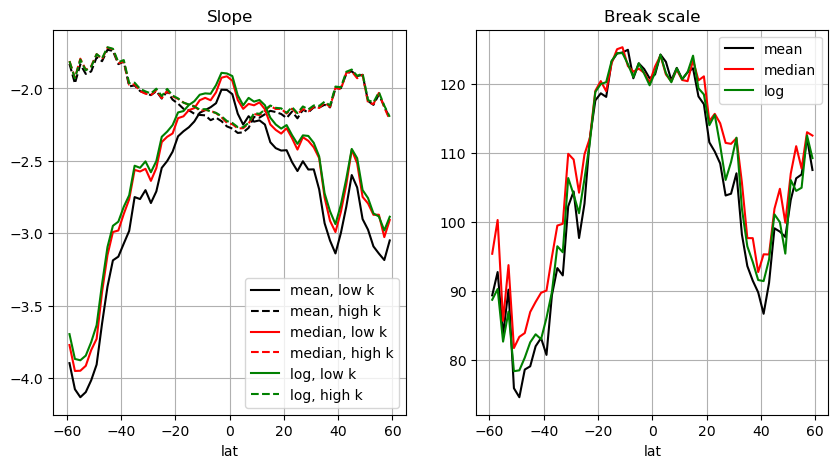

In [299]:
fig ,axs = plt.subplots(1,2,figsize=(10,5))
for method,c in zip(['mean','median','log'], ['k','r','g']):
    ds_boxes = build_box_dataset(ds_segments, box_deg=BOX_DEG,min_sampling_fraction=0.15,method=method)
    ds_sep_adapt = wrap_separation_scale_adaptive(
    ds_boxes,
    low_k_band=(1/150, 1/60),   
    high_k_band=(1/40, 1/10),
    smooth_window=15,
    verbose=False,
    )
    slope_lo = convert2latlon(ds_sep_adapt.slope_low_k,ds_sep_adapt.lat_mean,ds_sep_adapt.lon_mean)
    slope_hi = convert2latlon(ds_sep_adapt.slope_high_k,ds_sep_adapt.lat_mean,ds_sep_adapt.lon_mean)
    scale = convert2latlon(ds_sep_adapt.separation_wavelength,ds_sep_adapt.lat_mean,ds_sep_adapt.lon_mean)
    slope_lo.mean('lon').plot(ax=axs[0],c=c,label=f'{method}, low k')
    slope_hi.mean('lon').plot(ax=axs[0],c=c,ls='--',label=f'{method}, high k')
    scale.mean('lon').plot(ax=axs[1],c=c,label=f'{method}')
for ax in axs:
    ax.legend();
    ax.grid();
axs[0].set_title('Slope')
axs[1].set_title('Break scale')

## Testing window

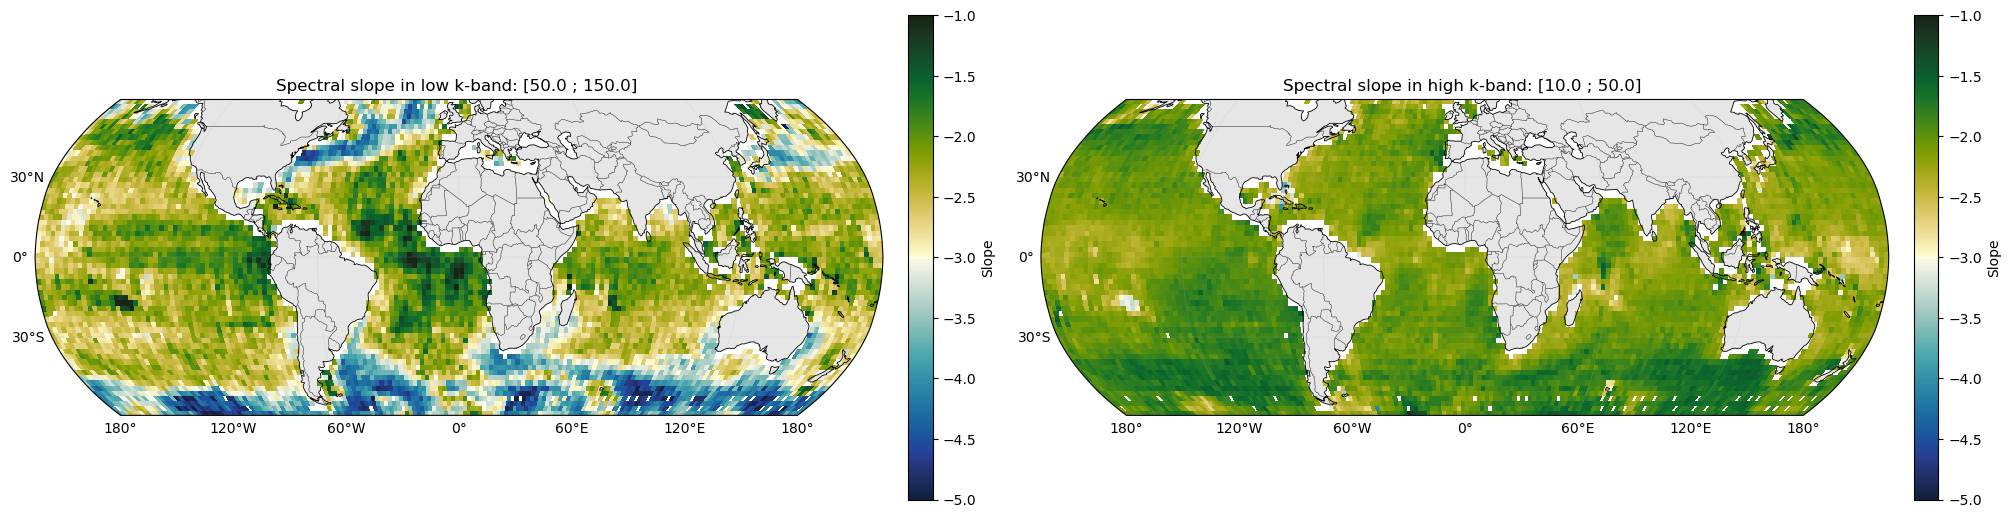

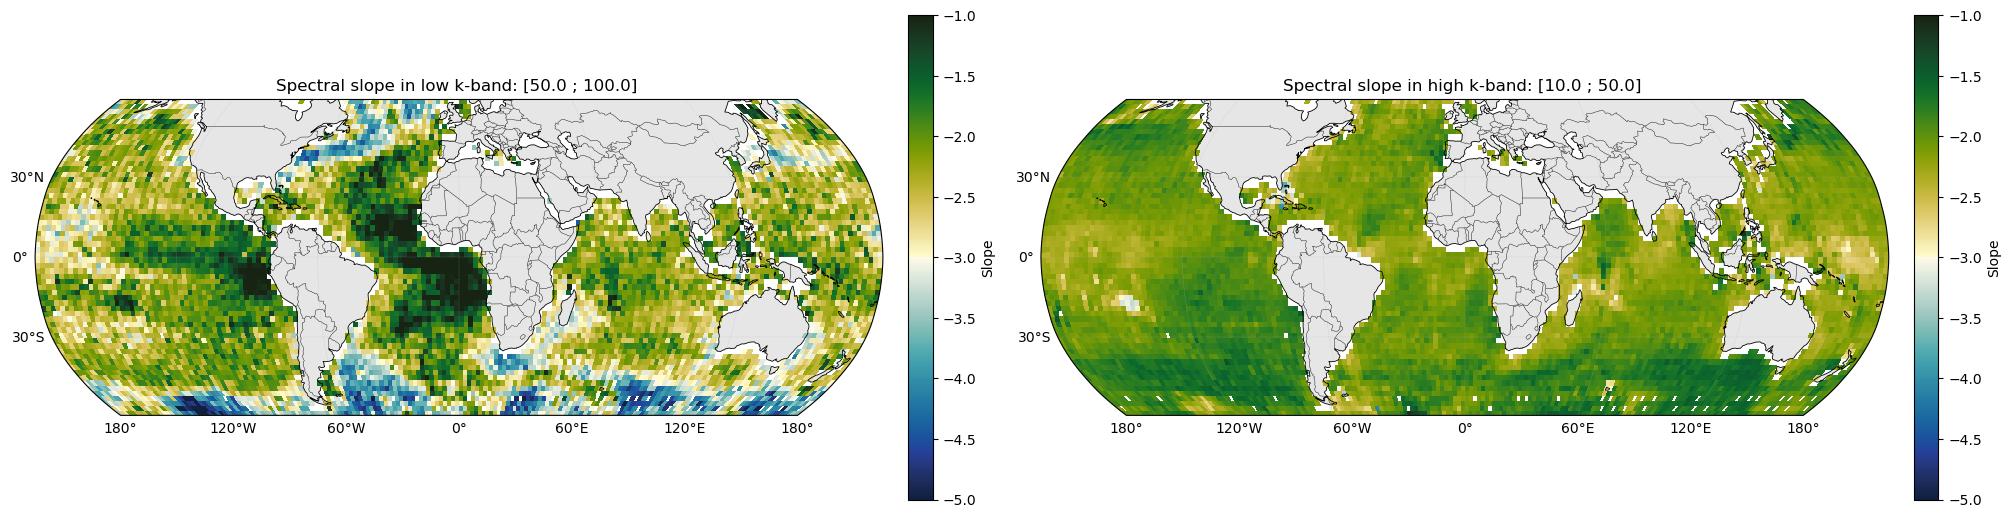

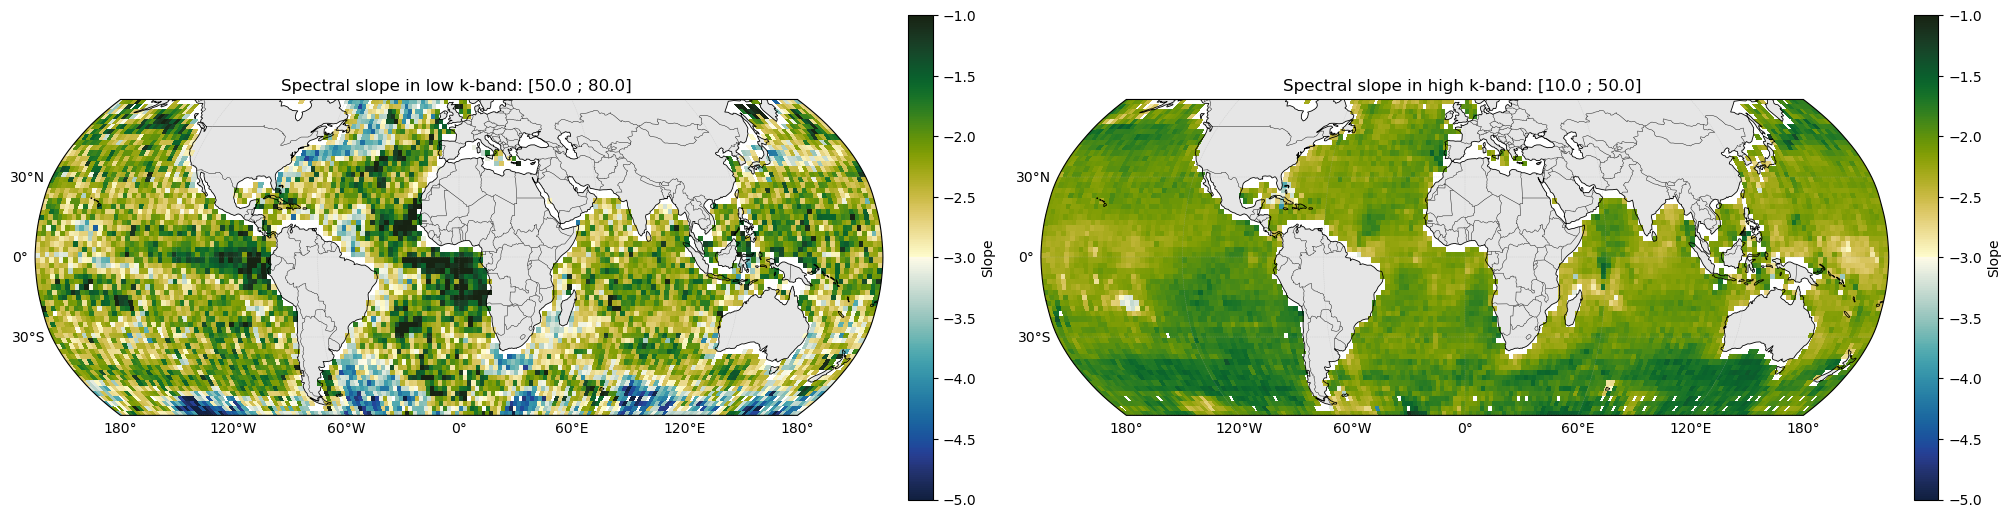

In [300]:
ds_boxes = build_box_dataset(ds_segments, box_deg=BOX_DEG,min_sampling_fraction=0.15,method='mean')
for klow,khigh in zip([(1/150,1/50),(1/100,1/50),(1/80,1/50)],[(1/50,1/10),(1/50,1/10), (1/50,1/10)]):
    ds_sep_adapt = wrap_separation_scale_adaptive(
    ds_boxes,
    low_k_band=klow,   
    high_k_band=khigh,
    smooth_window=15,
    verbose=False,
    )
    fig, axs = plt.subplots(1,2,figsize=(20,7),subplot_kw={"projection": ccrs.Robinson()},constrained_layout=True)

    fig_, ax = plot_box(ds_sep_adapt.slope_low_k,
                       ds_sep_adapt.lon_mean,ds_sep_adapt.lat_mean, vmin=-5.0, vmax=-1.0,
                        fig = fig, ax=axs[0],
                       title = f"Spectral slope in low k-band: [{1/klow[1]:.1f} ; {1/klow[0]:.1f}] ", label=r'Slope',
                      cmap=cmocean.cm.delta)
    ax.set_extent([-180,180,-60,60])

    fig_, ax = plot_box(ds_sep_adapt.slope_high_k,
                       ds_sep_adapt.lon_mean,ds_sep_adapt.lat_mean, vmin=-5.0, vmax=-1.0,
                       fig = fig, ax=axs[1],
                       title = f"Spectral slope in high k-band: [{1/khigh[1]:.1f} ; {1/khigh[0]:.1f}] ", label=r'Slope',
                      cmap=cmocean.cm.delta)
    ax.set_extent([-180,180,-60,60])

    

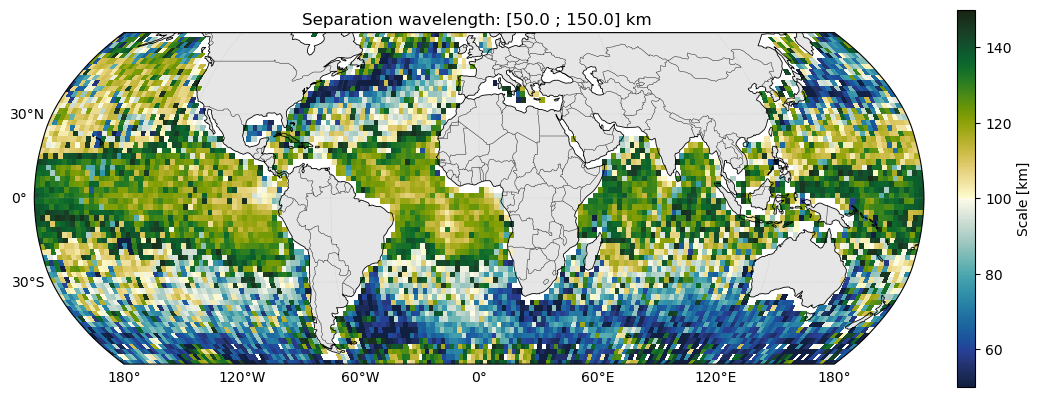

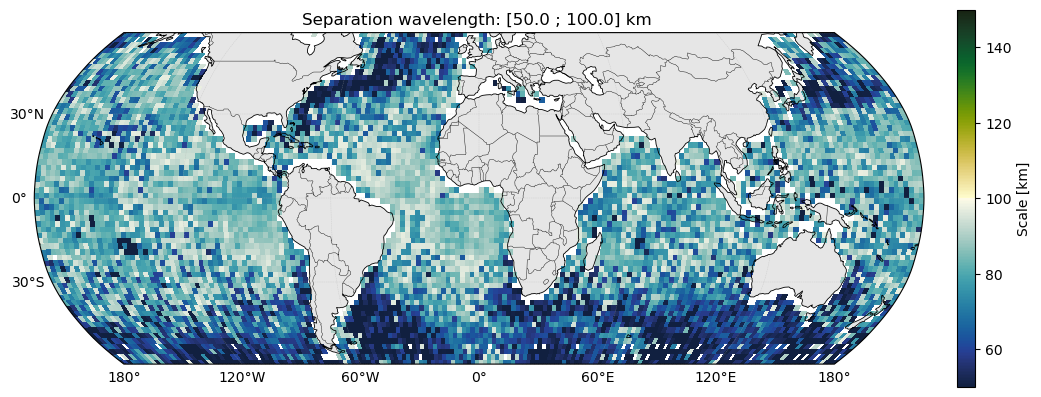

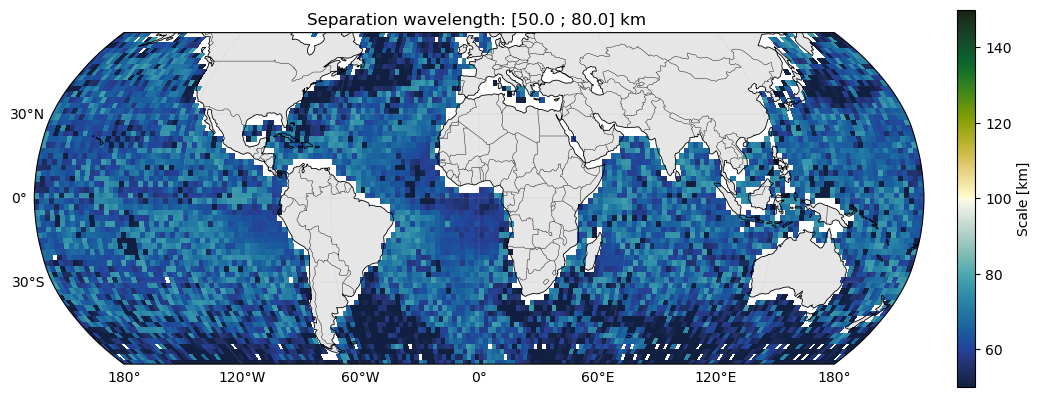

In [301]:
for klow,khigh in zip([(1/150,1/50),(1/100,1/50),(1/80,1/50)],[(1/50,1/10),(1/50,1/10), (1/50,1/10)]):
    ds_sep_adapt = wrap_separation_scale_adaptive(
    ds_boxes,
    low_k_band=klow,   
    high_k_band=khigh,
    smooth_window=15,
    verbose=False,
    )
    
    fig, ax = plot_box(ds_sep_adapt.separation_wavelength,
                       ds_sep_adapt.lon_mean,ds_sep_adapt.lat_mean, vmin=50.0, vmax=150.0,
                       title = f"Separation wavelength: [{1/klow[1]:.1f} ; {1/klow[0]:.1f}] km ", label=r'Scale [km]',
                      cmap=cmocean.cm.delta)
    ax.set_extent([-180,180,-60,60])

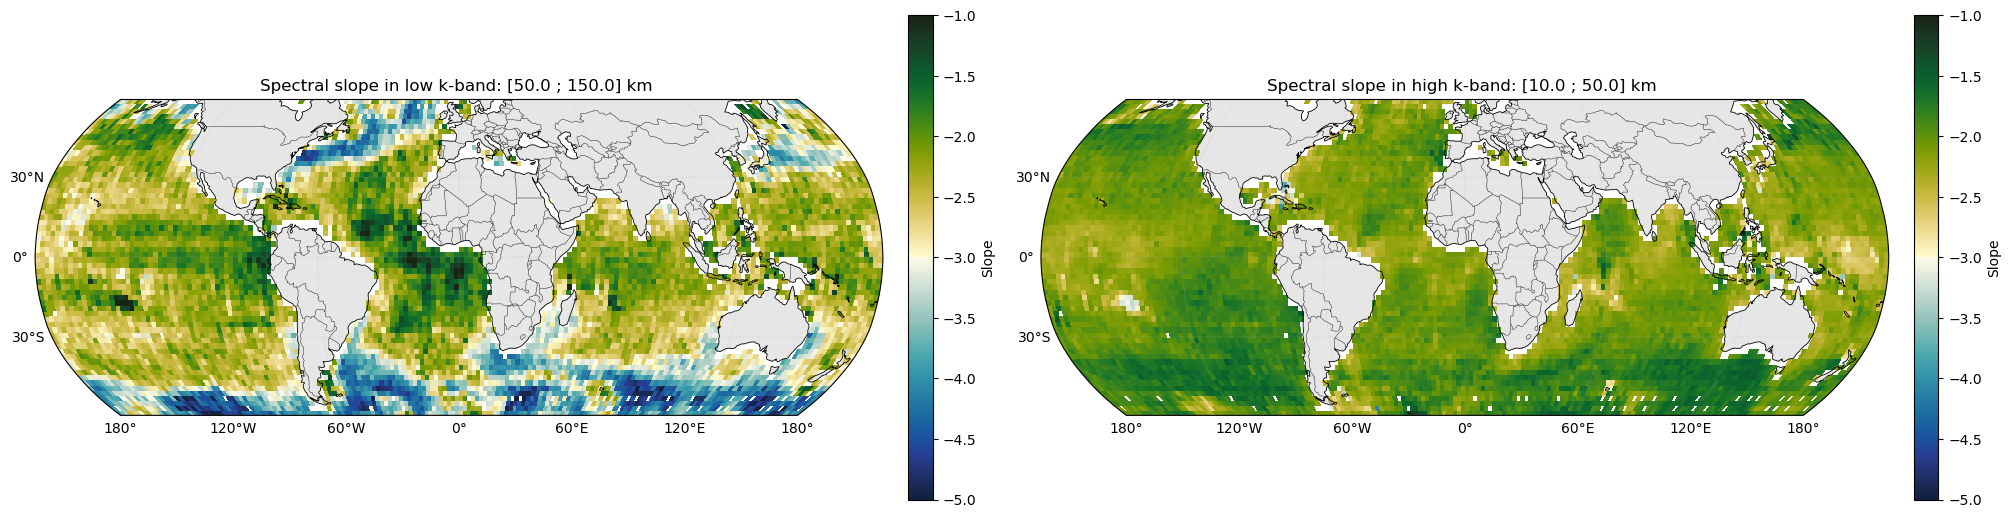

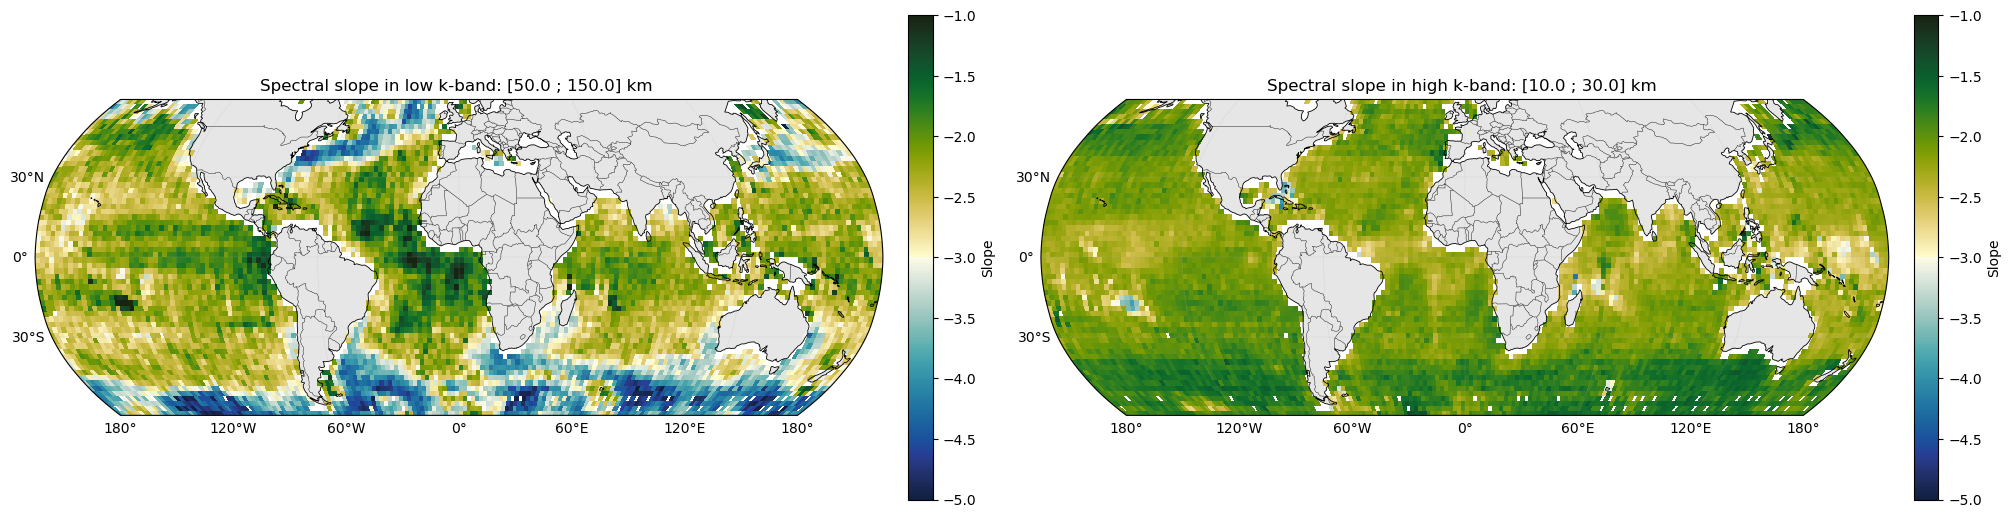

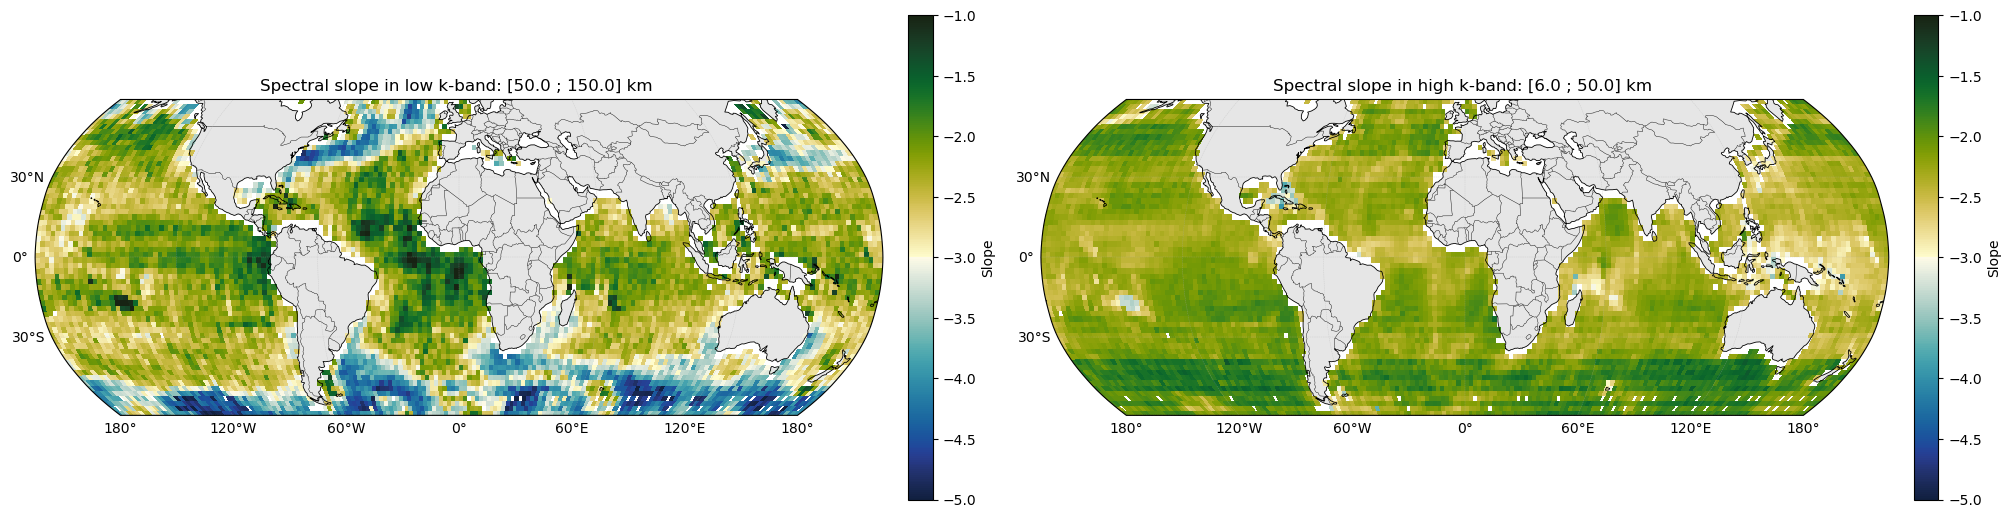

In [302]:
for khigh in [(1/50,1/10),(1/30,1/10), (1/50,1/6)]:
    ds_sep_adapt = wrap_separation_scale_adaptive(
    ds_boxes,
    low_k_band=(1/150,1/50),   
    high_k_band=khigh,
    smooth_window=15,
    verbose=False,
    )
    fig, axs = plt.subplots(1,2,figsize=(20,7),subplot_kw={"projection": ccrs.Robinson()},constrained_layout=True)

    fig_, ax = plot_box(ds_sep_adapt.slope_low_k,
                       ds_sep_adapt.lon_mean,ds_sep_adapt.lat_mean, vmin=-5.0, vmax=-1.0,
                        fig = fig, ax=axs[0],
                       title = f"Spectral slope in low k-band: [50.0 ; 150.0] km ", label=r'Slope',
                      cmap=cmocean.cm.delta)
    ax.set_extent([-180,180,-60,60])

    fig_, ax = plot_box(ds_sep_adapt.slope_high_k,
                       ds_sep_adapt.lon_mean,ds_sep_adapt.lat_mean, vmin=-5.0, vmax=-1.0,
                       fig = fig, ax=axs[1],
                       title = f"Spectral slope in high k-band: [{1/khigh[1]:.1f} ; {1/khigh[0]:.1f}] km ", label=r'Slope',
                      cmap=cmocean.cm.delta)
    ax.set_extent([-180,180,-60,60])

    

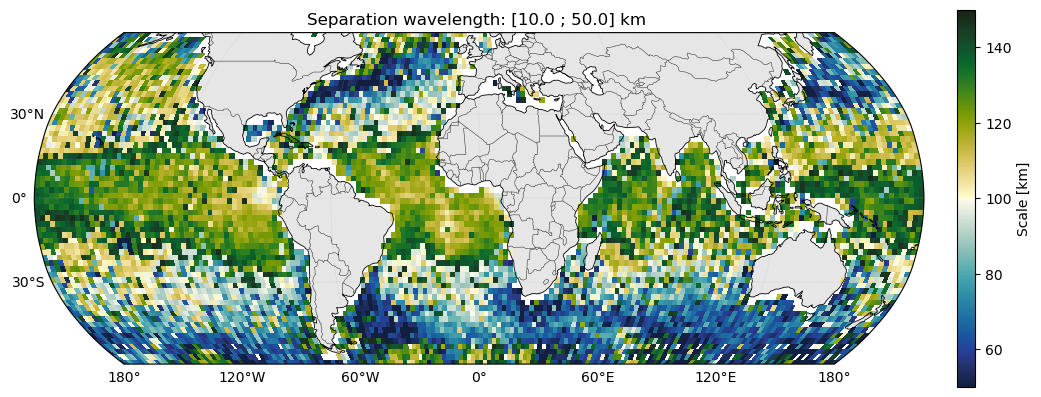

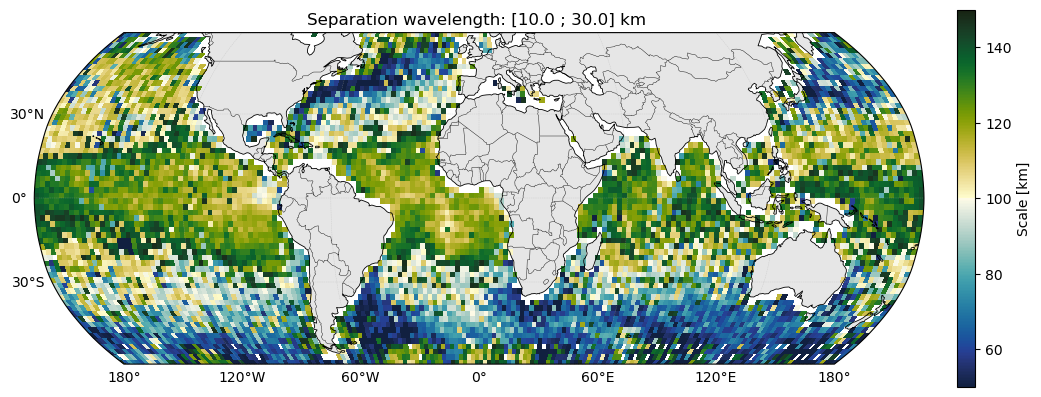

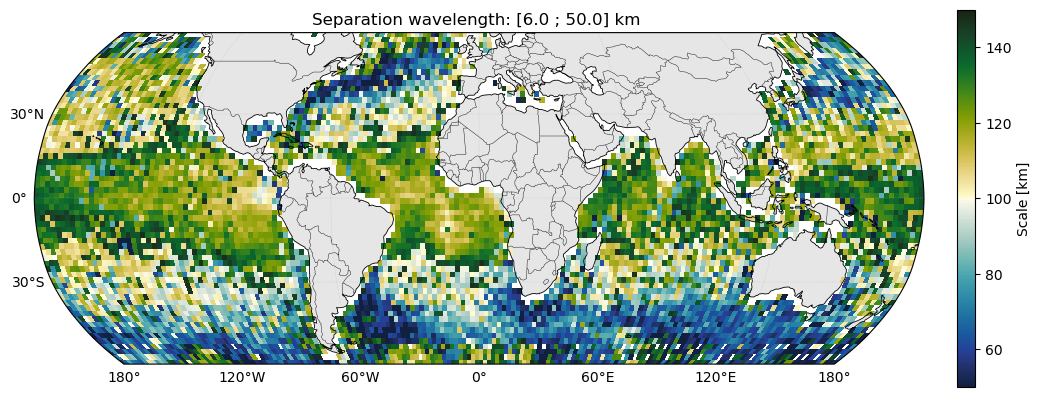

In [303]:
for khigh in [(1/50,1/10),(1/30,1/10), (1/50,1/6)]:
    ds_sep_adapt = wrap_separation_scale_adaptive(
    ds_boxes,
    low_k_band=(1/150,1/50),   
    high_k_band=khigh,
    smooth_window=15,
    verbose=False,
    )
    
    fig, ax = plot_box(ds_sep_adapt.separation_wavelength,
                       ds_sep_adapt.lon_mean,ds_sep_adapt.lat_mean, vmin=50.0, vmax=150.0,
                       title = f"Separation wavelength: [{1/khigh[1]:.1f} ; {1/khigh[0]:.1f}] km ", label=r'Scale [km]',
                      cmap=cmocean.cm.delta)
    ax.set_extent([-180,180,-60,60])

Text(0.5, 1.0, 'Break scale')

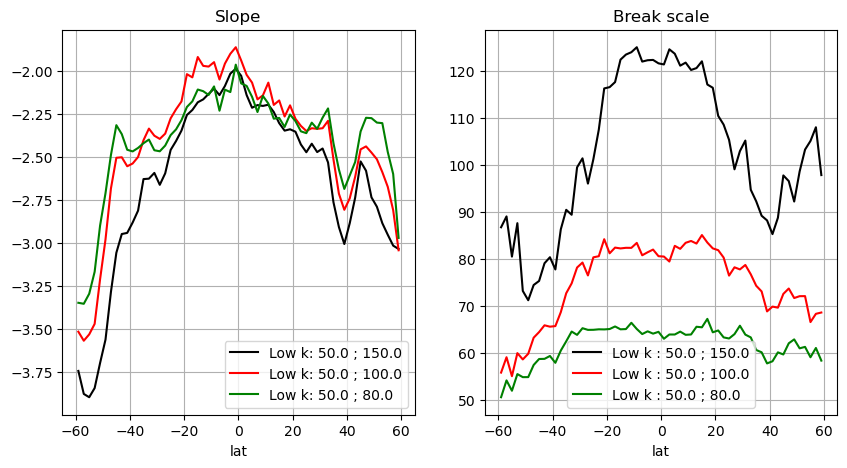

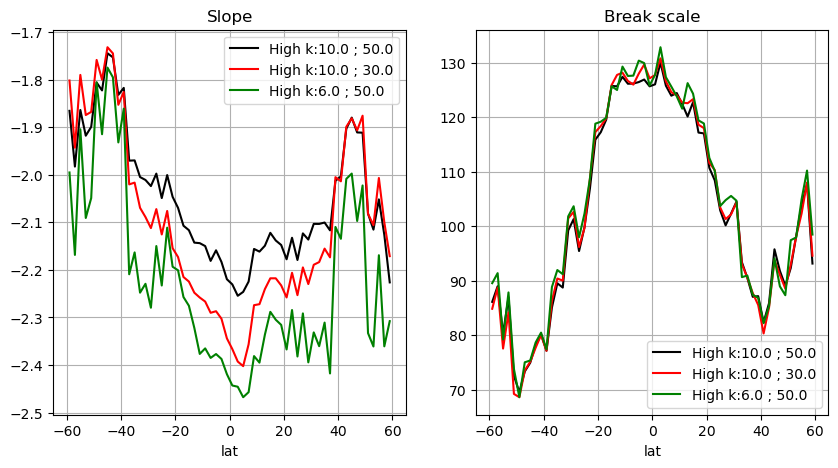

In [304]:
fig ,axs = plt.subplots(1,2,figsize=(10,5))
for klow,c in zip([(1/150,1/50),(1/100,1/50),(1/80,1/50)],['k','r','g']):
    ds_sep_adapt = wrap_separation_scale_adaptive(
    ds_boxes,
    low_k_band=klow,   
    high_k_band=(1/50,1/10),
    smooth_window=15,
    verbose=False,
    )
    slope_lo = convert2latlon(ds_sep_adapt.slope_low_k,ds_sep_adapt.lat_mean,ds_sep_adapt.lon_mean)
    #slope_hi = convert2latlon(ds_sep_adapt.slope_high_k,ds_sep_adapt.lat_mean,ds_sep_adapt.lon_mean)
    scale = convert2latlon(ds_sep_adapt.separation_wavelength,ds_sep_adapt.lat_mean,ds_sep_adapt.lon_mean)
    slope_lo.mean('lon').plot(ax=axs[0],c=c,label=f'Low k: {1/klow[1]:.1f} ; {1/klow[0]:.1f}')
    #slope_hi.mean('lon').plot(ax=axs[0],c=c,ls='--',label=f'{method}, high k')
    scale.mean('lon').plot(ax=axs[1],c=c,label=f'Low k : {1/klow[1]:.1f} ; {1/klow[0]:.1f}')
for ax in axs:
    ax.legend();
    ax.grid();
axs[0].set_title('Slope')
axs[1].set_title('Break scale')


fig ,axs = plt.subplots(1,2,figsize=(10,5))
for khigh,c in zip([(1/50,1/10),(1/30,1/10),(1/50,1/6)],['k','r','g']):
    ds_sep_adapt = estimate_separation_scale_adaptive(
    ds_boxes,
    low_k_band=(1/150,1/50),   
    high_k_band=khigh,
    smooth_window=15,
    verbose=False,
    )
    #slope_lo = convert2latlon(ds_sep_adapt.slope_low_k,ds_sep_adapt.lat_mean,ds_sep_adapt.lon_mean)
    slope_hi = convert2latlon(ds_sep_adapt.slope_high_k,ds_sep_adapt.lat_mean,ds_sep_adapt.lon_mean)
    scale = convert2latlon(ds_sep_adapt.separation_wavelength,ds_sep_adapt.lat_mean,ds_sep_adapt.lon_mean)
    #slope_lo.mean('lon').plot(ax=axs[0],c=c,label=f'High k:{1/khigh[1]:.1f} ; {1/khigh[0]:.1f}')
    slope_hi.mean('lon').plot(ax=axs[0],c=c,label=f'High k:{1/khigh[1]:.1f} ; {1/khigh[0]:.1f}')
    scale.mean('lon').plot(ax=axs[1],c=c,label=f'High k:{1/khigh[1]:.1f} ; {1/khigh[0]:.1f}')
for ax in axs:
    ax.legend();
    ax.grid();
axs[0].set_title('Slope')
axs[1].set_title('Break scale')

## Individual segments test

In [402]:
latc, lonc = 41.0,305.0
dl = .6

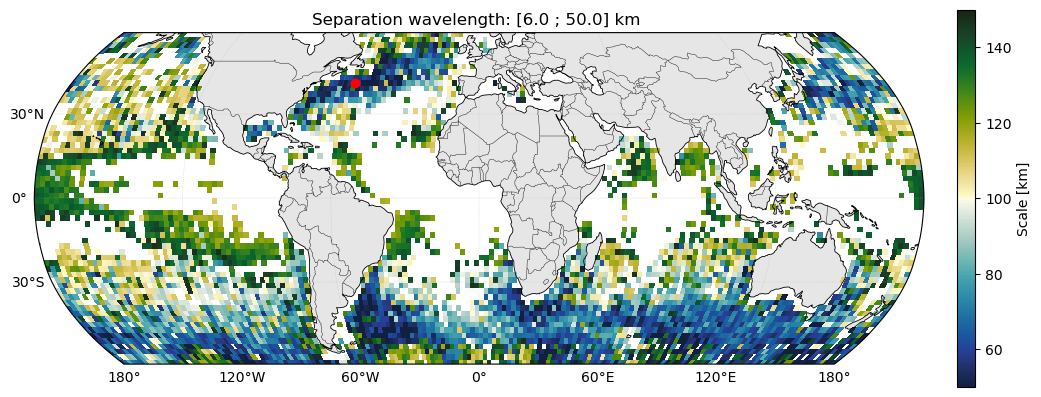

In [403]:
fig, ax = plot_box(ds_sep_adapt.separation_wavelength,
                       ds_sep_adapt.lon_mean,ds_sep_adapt.lat_mean, vmin=50.0, vmax=150.0,
                       title = f"Separation wavelength: [{1/khigh[1]:.1f} ; {1/khigh[0]:.1f}] km ", label=r'Scale [km]',
                      cmap=cmocean.cm.delta)
ax.set_extent([-180,180,-60,60]);
ax.scatter(lonc,latc,transform=ccrs.PlateCarree(),c='r')

In [404]:
box = ds_boxes.where((ds_boxes.lon_mean<=lonc+BOX_DEG/2) & (ds_boxes.lon_mean>=lonc-BOX_DEG/2) &
               (ds_boxes.lat_mean<=latc+BOX_DEG/2) & (ds_boxes.lat_mean>=latc-BOX_DEG/2)
               ,drop=True)#.isel(box=0)

bin_segs = ds_segments.where((ds_segments.lon_mean<=lonc+dl) & (ds_segments.lon_mean>=lonc-dl) &
               (ds_segments.lat_mean<=latc+dl) & (ds_segments.lat_mean>=latc-dl)
               ,drop=True)

In [405]:
box

<xarray.Dataset> Size: 4kB
Dimensions:            (box: 1, wavenumber: 250)
Coordinates:
  * box                (box) int64 8B 6734
    lat_mean           (box) float64 8B 41.0
    lon_mean           (box) float64 8B 305.0
  * wavenumber         (wavenumber) float64 2kB 0.0 0.0009994 ... 0.2479 0.2489
Data variables:
    mean_psd           (box, wavenumber) float64 2kB 2.156 15.51 ... 1.473e-05
    n_segments         (box) float64 8B 41.0
    sampling_fraction  (box) float64 8B 0.5694
Attributes:
    box_size_deg:           2.0
    min_sampling_fraction:  0.15

In [406]:
print('----------- General stats--------------')
print(f"Number of boxes selected: {box.box.size}")
print(f"Number of segments: {bin_segs.segment.size}")
print(f"Number of segments in left swath: {bin_segs.where(bin_segs.swath=='left',drop=True).segment.size}")
print(f"Number of segments in right swath: {bin_segs.where(bin_segs.swath=='right',drop=True).segment.size}")
print('----------- Seasonal stats--------------')
print(f"Number of months covered: {np.unique(bin_segs.month).size}")
for m in np.unique(bin_segs.month):
    print(f"Number of segment during month {int(m)} : {bin_segs.where(bin_segs.month==np.unique(bin_segs.month)[int(m-1)], drop=True).segment.size}")

----------- General stats--------------
Number of boxes selected: 1
Number of segments: 27
Number of segments in left swath: 14
Number of segments in right swath: 13
----------- Seasonal stats--------------
Number of months covered: 11
Number of segment during month 2 : 2
Number of segment during month 3 : 3
Number of segment during month 4 : 3
Number of segment during month 5 : 2
Number of segment during month 6 : 1
Number of segment during month 7 : 3
Number of segment during month 8 : 3
Number of segment during month 9 : 2
Number of segment during month 10 : 3
Number of segment during month 11 : 3


IndexError: index 11 is out of bounds for axis 0 with size 11

In [407]:
smooth_window=15
n_interp = 200
search_range=None
low_k_band = (1/150,1/50)
high_k_band = (1/50,1/10)

def individual_slope(box,low_k_band, high_k_band,
                     psd_var = 'mean_psd',
                     smooth_window = smooth_window,
                     search_range = search_range,
                     n_interp=n_interp):
    wavenumber = box['wavenumber'].values
    psd_all    = box[psd_var].values
    n_boxes    = psd_all.shape[0]
    
    
    k_valid = wavenumber > 0
    wavenumber = wavenumber[k_valid]
    psd_all = psd_all[:,k_valid]
    log_k_orig = np.log10(wavenumber)
    
    if smooth_window % 2 == 0:
        smooth_window += 1
    
    log_k_uniform = np.linspace(log_k_orig.min(), log_k_orig.max(), n_interp)
    dlogk = log_k_uniform[1] - log_k_uniform[0]
    
    if search_range is None:
        k_lo = low_k_band[0]
        k_hi = high_k_band[1]
    else:
        k_lo, k_hi = search_range
    search_mask = (10**log_k_uniform >= k_lo) & (10**log_k_uniform <= k_hi)
    
    sep_k, threshold,slope_low, slope_high = estimate_separation_scale_adaptative(psd_all[0],wavenumber,log_k_uniform,dlogk,
                                                                                          search_mask,
                                                                                          low_k_band, high_k_band,
                                                                                         smooth_window = smooth_window,
                                                                                         polyorder=2,
                                                                                         search_range = search_range,
                                                                                         n_interp=n_interp,
                                                                                         verbose=False)
    return sep_k, threshold,slope_low, slope_high

In [408]:
sep_k, threshold,slope_low, slope_high = individual_slope(box,low_k_band, high_k_band,
                     smooth_window = smooth_window,
                     search_range = search_range,
                     n_interp=n_interp)

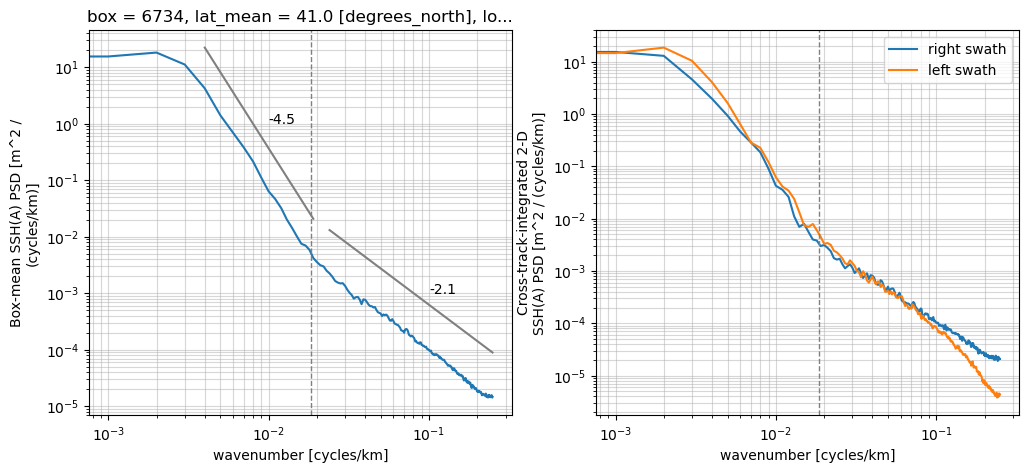

In [409]:
fig,axs = plt.subplots(1,2,figsize=(12,5))

ax=axs[0]
box.mean_psd.plot(ax=ax,xscale='log',yscale='log')
# Reference slopes
k_ref = box["wavenumber"].values[4:20]
k0    = k_ref[4]
psd0 = 1
ax.loglog(k_ref, psd0 * (k_ref / k0) ** slope_low,color='gray')
ax.text(0.01,1,f'{slope_low:.1f}')
k_ref = box["wavenumber"].values[24:]
k0    = k_ref[24]
psd0 = 3e-3
ax.loglog(k_ref, psd0 * (k_ref / k0) ** slope_high,color='gray')
ax.text(0.1,0.001,f'{slope_high:.1f}')

ax.grid(True, which='both', alpha=0.5)

ax=axs[1]
bin_segs.where(bin_segs.swath=='right',drop=True).psd.mean('segment').plot(ax=ax,xscale='log',yscale='log',label='right swath')
bin_segs.where(bin_segs.swath=='left',drop=True).psd.mean('segment').plot(ax=ax,xscale='log',yscale='log',label='left swath')
ax.grid(True, which='both', alpha=0.5);
ax.legend();

for ax in axs:
    ax.axvline(sep_k,lw=1.0,ls='--',c='grey')

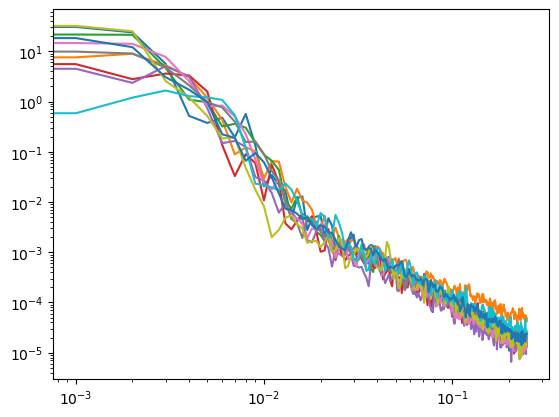

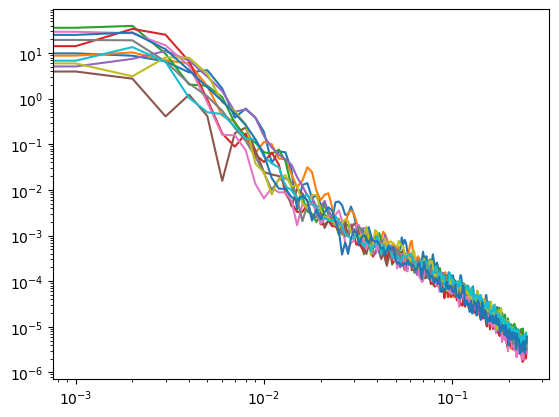

In [410]:
slope_lo,slope_hi = [], []
slope_lo_l,slope_hi_l = [], []
separation_k, separation_k_l = [],[]

fig,ax=plt.subplots()
for m in np.unique(bin_segs.month):
    try:
        seg_month_r = bin_segs.where((bin_segs.month==m) & (bin_segs.swath=='right'),drop=True).mean('segment').expand_dims('segment')
        #seg_month_l = bin_segs.where((bin_segs.month==m) & (bin_segs.swath=='right'),drop=True).mean('segment').expand_dims('segment')
        sep_k, threshold,slope_low, slope_high = individual_slope(seg_month_r,low_k_band, high_k_band,
                                                              psd_var='psd',
                                                              smooth_window = smooth_window,
                                                              search_range = search_range,n_interp=n_interp)
        separation_k.append(sep_k)
        slope_lo.append(slope_low)
        slope_hi.append(slope_high)
    except:
        separation_k.append(np.nan)
        slope_lo.append(np.nan)
        slope_hi.append(np.nan)
    
    
    ax.loglog(seg_month_r.wavenumber,seg_month_r['psd'][0])

fig,ax=plt.subplots()
for m in np.unique(bin_segs.month):
    try:
        seg_month_l = bin_segs.where((bin_segs.month==m) & (bin_segs.swath=='left'),drop=True).mean('segment').expand_dims('segment')
        #seg_month_l = bin_segs.where((bin_segs.month==m) & (bin_segs.swath=='right'),drop=True).mean('segment').expand_dims('segment')
        sep_k, threshold,slope_low, slope_high = individual_slope(seg_month_l,low_k_band, high_k_band,
                                                              psd_var='psd',
                                                              smooth_window = smooth_window,
                                                              search_range = search_range,n_interp=n_interp)
        separation_k_l.append(sep_k)
        slope_lo_l.append(slope_low)
        slope_hi_l.append(slope_high)
    except:
        separation_k_l.append(np.nan)
        slope_lo_l.append(np.nan)
        slope_hi_l.append(np.nan)
    
    
    ax.loglog(seg_month_l.wavenumber,seg_month_l['psd'][0])

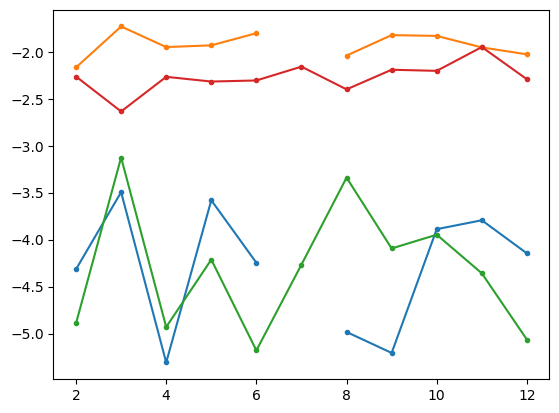

In [411]:
plt.plot(np.unique(bin_segs.month),slope_lo,marker='.')
plt.plot(np.unique(bin_segs.month),slope_hi,marker='.')

plt.plot(np.unique(bin_segs.month),slope_lo_l,marker='.')
plt.plot(np.unique(bin_segs.month),slope_hi_l,marker='.')